In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

In [8]:
data = pd.read_csv('Medicaldataset.csv', sep=',')

In [9]:
data.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [10]:
data.shape

(1319, 9)

In [11]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 1319


In [12]:
# Список колонок
data.columns

Index(['Age', 'Gender', 'Heart rate', 'Systolic blood pressure',
       'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin',
       'Result'],
      dtype='object')

In [13]:
data.dtypes

Age                           int64
Gender                        int64
Heart rate                    int64
Systolic blood pressure       int64
Diastolic blood pressure      int64
Blood sugar                 float64
CK-MB                       float64
Troponin                    float64
Result                       object
dtype: object

In [14]:
for col in data.columns:
    temp_null_count = data[data[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))

Age - 0
Gender - 0
Heart rate - 0
Systolic blood pressure - 0
Diastolic blood pressure - 0
Blood sugar - 0
CK-MB - 0
Troponin - 0
Result - 0


In [15]:
# Основные статистические характеристки набора данных
# count - непустые ячейки
# mean - среднее арифметическое 
# std - стандартное отклонение
# min - минимальное значение
# 25% - 25-й перцентиль
# 50% - 50-й перцентиль
# 75% - 75-й перцентиль
# max - максимальное значение
data.describe()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


In [16]:
#преобразуем Result в числа
data['Result_numeric'] = data['Result'].map({'negative': 0, 'positive': 1})

In [17]:
print(data[['Result', 'Result_numeric']].head(10))

     Result  Result_numeric
0  negative               0
1  positive               1
2  negative               0
3  positive               1
4  negative               0
5  negative               0
6  negative               0
7  positive               1
8  negative               0
9  negative               0


In [18]:
### Основные статистические характеристки набора данных
# count - непустые ячейки
# mean - среднее арифметическое 
# std - стандартное отклонение
# min - минимальное значение
# 25% - 25-й перцентиль
# 50% - 50-й перцентиль
# 75% - 75-й перцентиль
# max - максимальное значение
data.describe()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result_numeric
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942,0.614102
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568,0.486991
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000,0.000000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000,0.000000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000,1.000000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500,1.000000
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000,1.000000


In [19]:
data['Result_numeric'].unique()

array([0, 1])

In [20]:
data['Result_numeric'].dtype

dtype('int64')

Text(0.5, 1.0, 'Зависимость между Troponin и CK-MB')

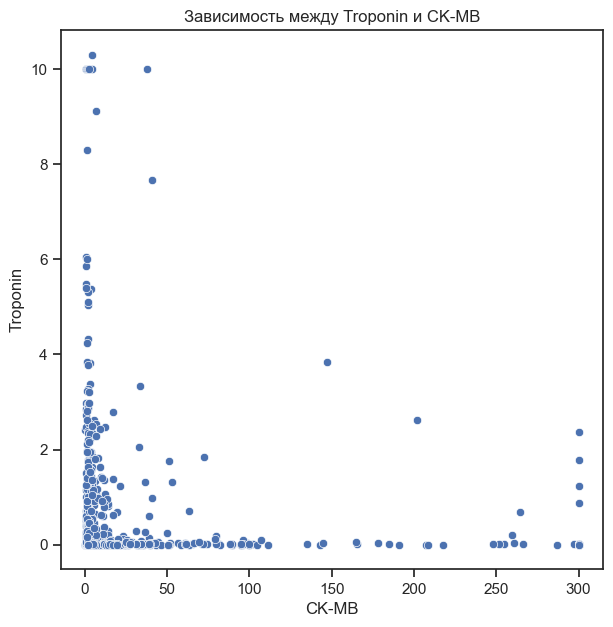

In [21]:
fig, ax = plt.subplots(figsize=(7,7)) 
sns.scatterplot(ax=ax, x='CK-MB', y='Troponin', data=data)
ax.set_title('Зависимость между Troponin и CK-MB', fontsize=12)

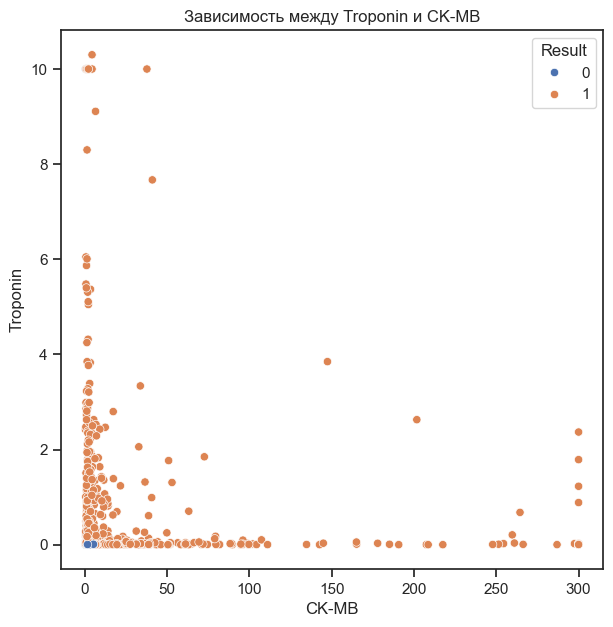

In [22]:
fig, ax = plt.subplots(figsize=(7, 7))
sns.scatterplot(ax=ax, x='CK-MB', y='Troponin', data=data, hue='Result_numeric')
ax.set_title('Зависимость между Troponin и CK-MB', fontsize=12)
plt.legend(title='Result')

Text(0.5, 1.0, 'Зависимость между Systolic blood pressure и Diastolic blood pressure')

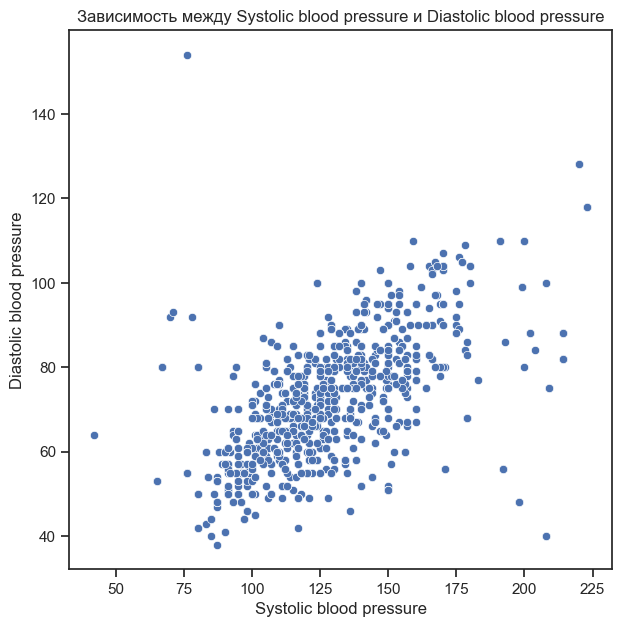

In [23]:
fig, ax = plt.subplots(figsize=(7,7)) 
sns.scatterplot(ax=ax, x='Systolic blood pressure', y='Diastolic blood pressure', data=data)
ax.set_title('Зависимость между Systolic blood pressure и Diastolic blood pressure', fontsize=12)

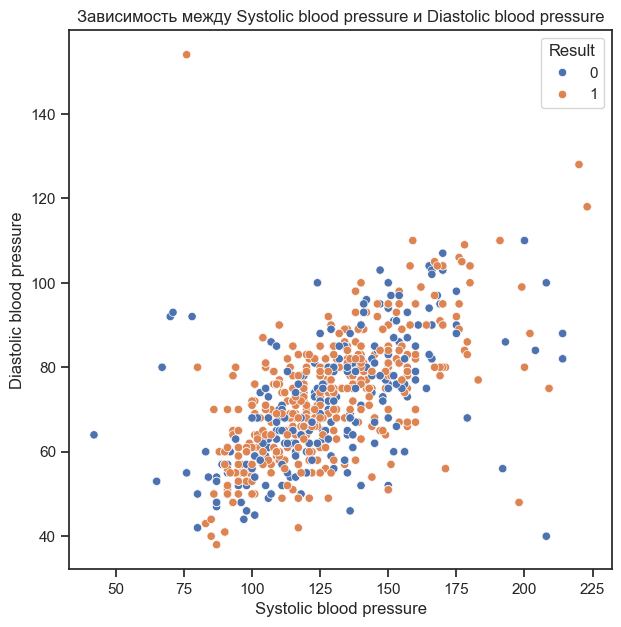

In [24]:
fig, ax = plt.subplots(figsize=(7,7)) 
sns.scatterplot(ax=ax, x='Systolic blood pressure', y='Diastolic blood pressure', data=data, hue='Result_numeric')
ax.set_title('Зависимость между Systolic blood pressure и Diastolic blood pressure', fontsize=12)
plt.legend(title='Result')

/var/folders/5x/lbd8871x0gg1k9cphlmq52500000gn/T/ipykernel_7957/2203468111.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Blood sugar'])


<Axes: xlabel='Blood sugar', ylabel='Density'>

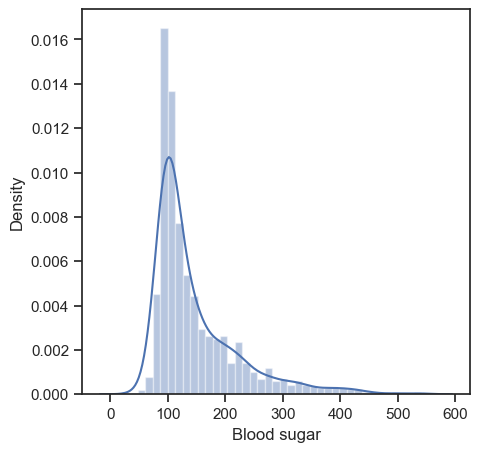

In [25]:
fig, ax = plt.subplots(figsize=(5,5)) 
sns.distplot(data['Blood sugar'])

/var/folders/5x/lbd8871x0gg1k9cphlmq52500000gn/T/ipykernel_7957/3559670932.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Heart rate'])


<Axes: xlabel='Heart rate', ylabel='Density'>

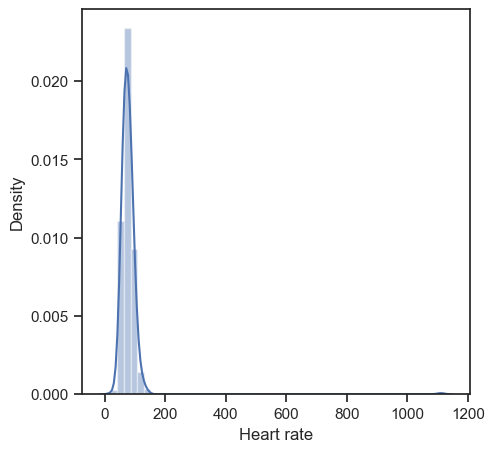

In [26]:
fig, ax = plt.subplots(figsize=(5,5)) 
sns.distplot(data['Heart rate'])

/var/folders/5x/lbd8871x0gg1k9cphlmq52500000gn/T/ipykernel_7957/1845181558.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Age'])


<Axes: xlabel='Age', ylabel='Density'>

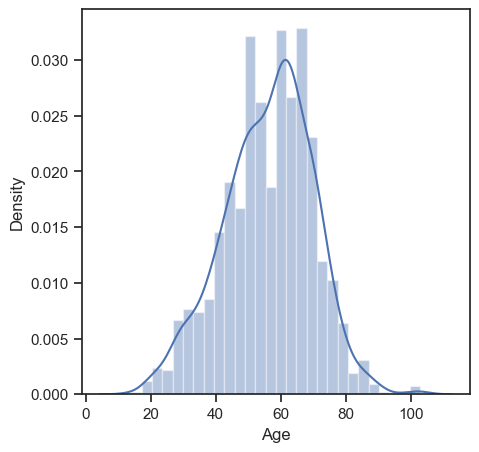

In [27]:
fig, ax = plt.subplots(figsize=(5,5)) 
sns.distplot(data['Age'])

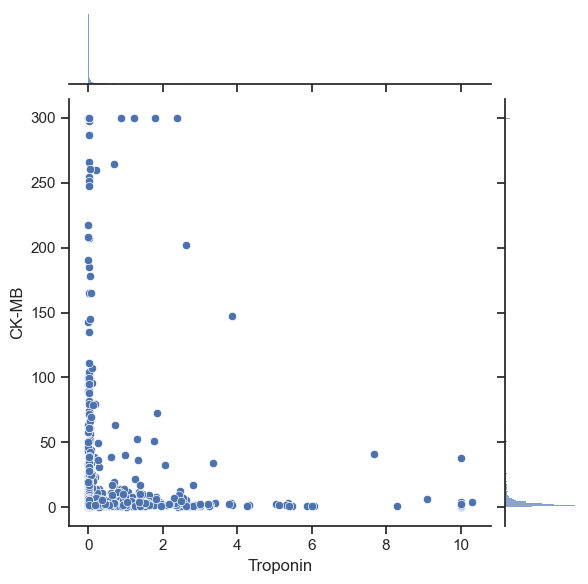

In [28]:
sns.jointplot(x='Troponin', y='CK-MB', data=data)

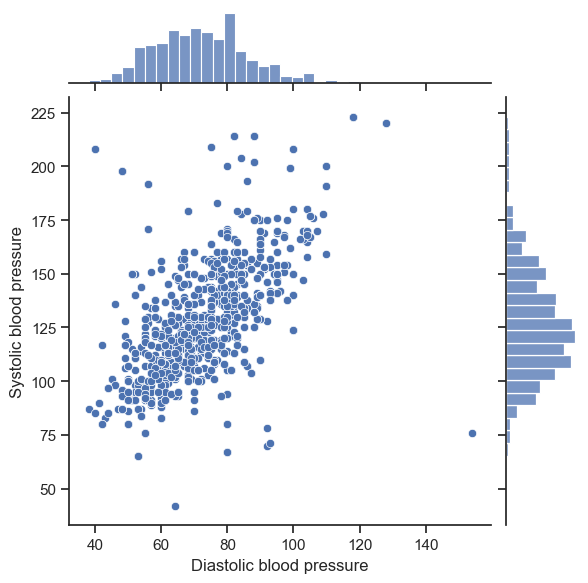

In [29]:
sns.jointplot(x='Diastolic blood pressure', y='Systolic blood pressure', data=data)

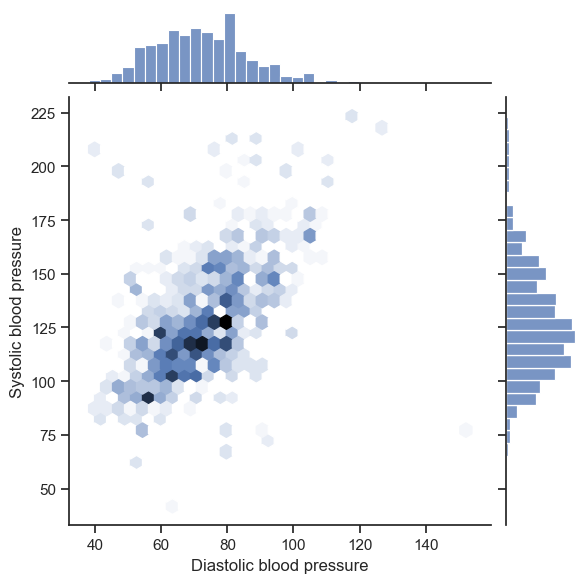

In [30]:
sns.jointplot(x='Diastolic blood pressure', y='Systolic blood pressure', data=data, kind='hex')

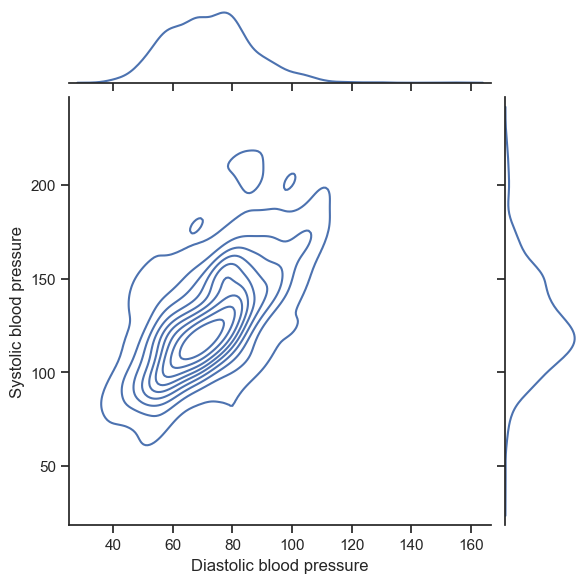

In [31]:
sns.jointplot(x='Diastolic blood pressure', y='Systolic blood pressure', data=data, kind='kde')

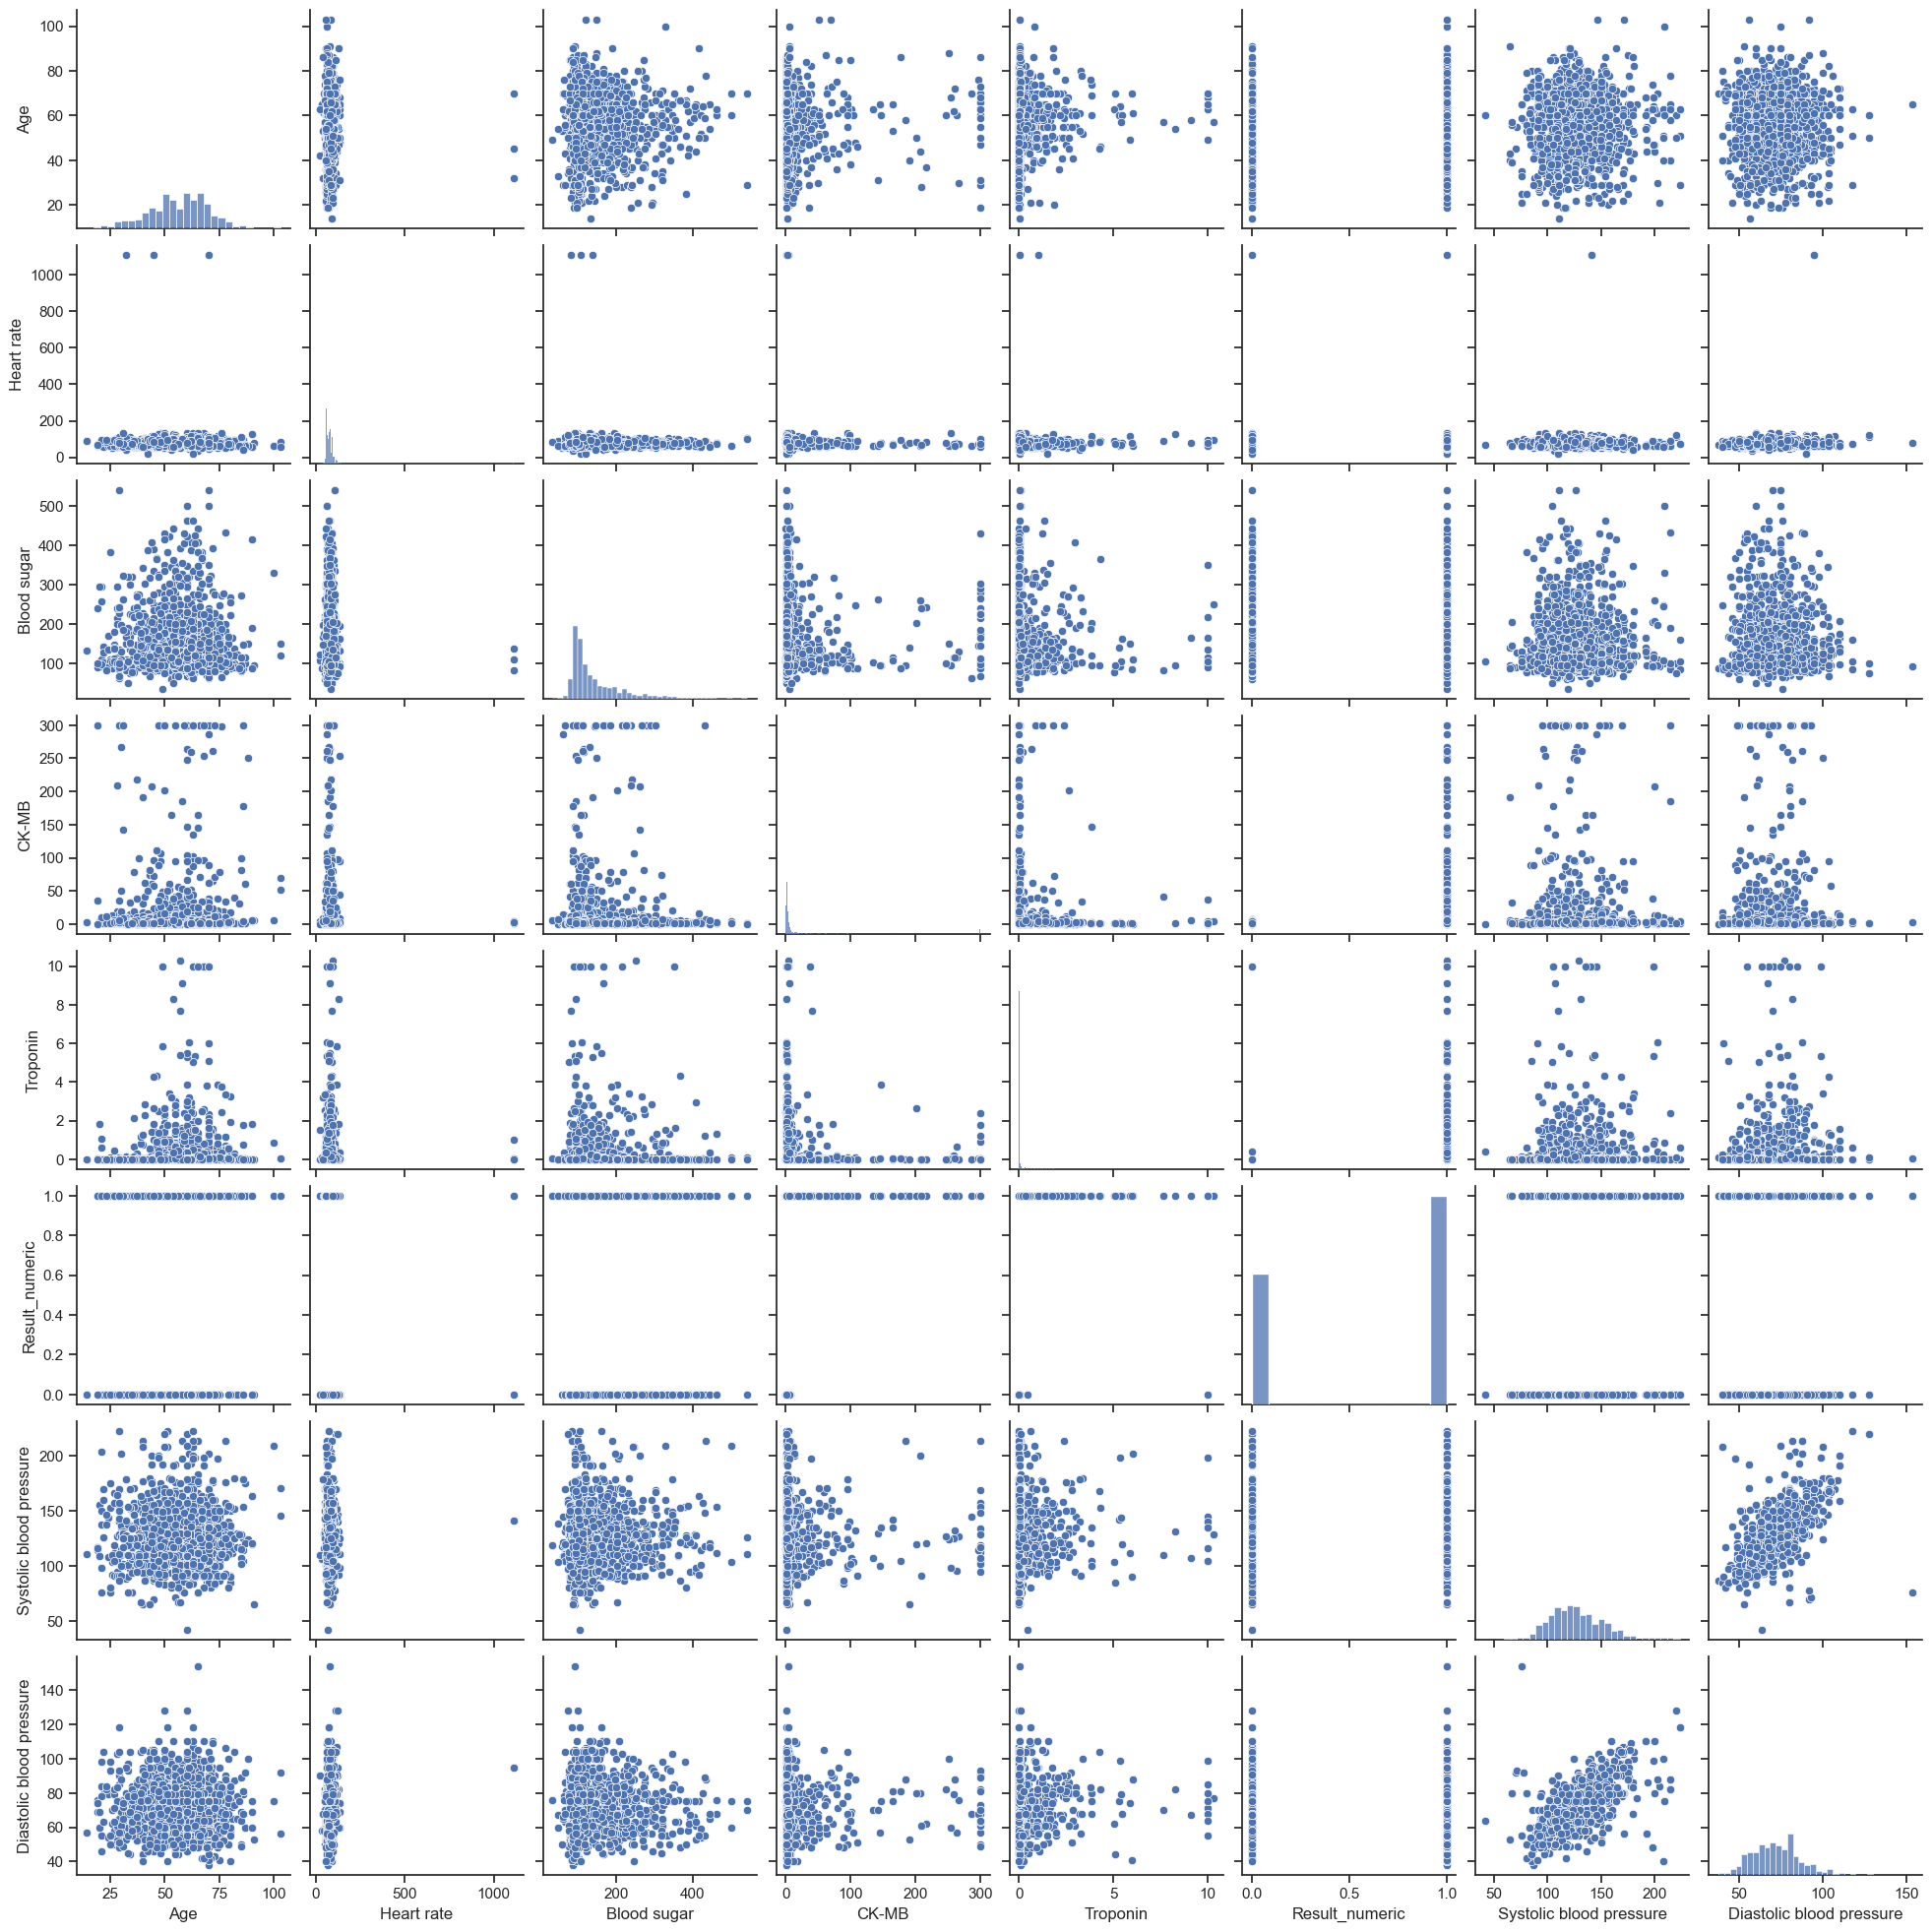

In [32]:
pairplot_features = ['Age', 'Heart rate', 'Blood sugar', 'CK-MB', 'Troponin', 'Result_numeric', 'Systolic blood pressure', 'Diastolic blood pressure']
sns.pairplot(data[pairplot_features])

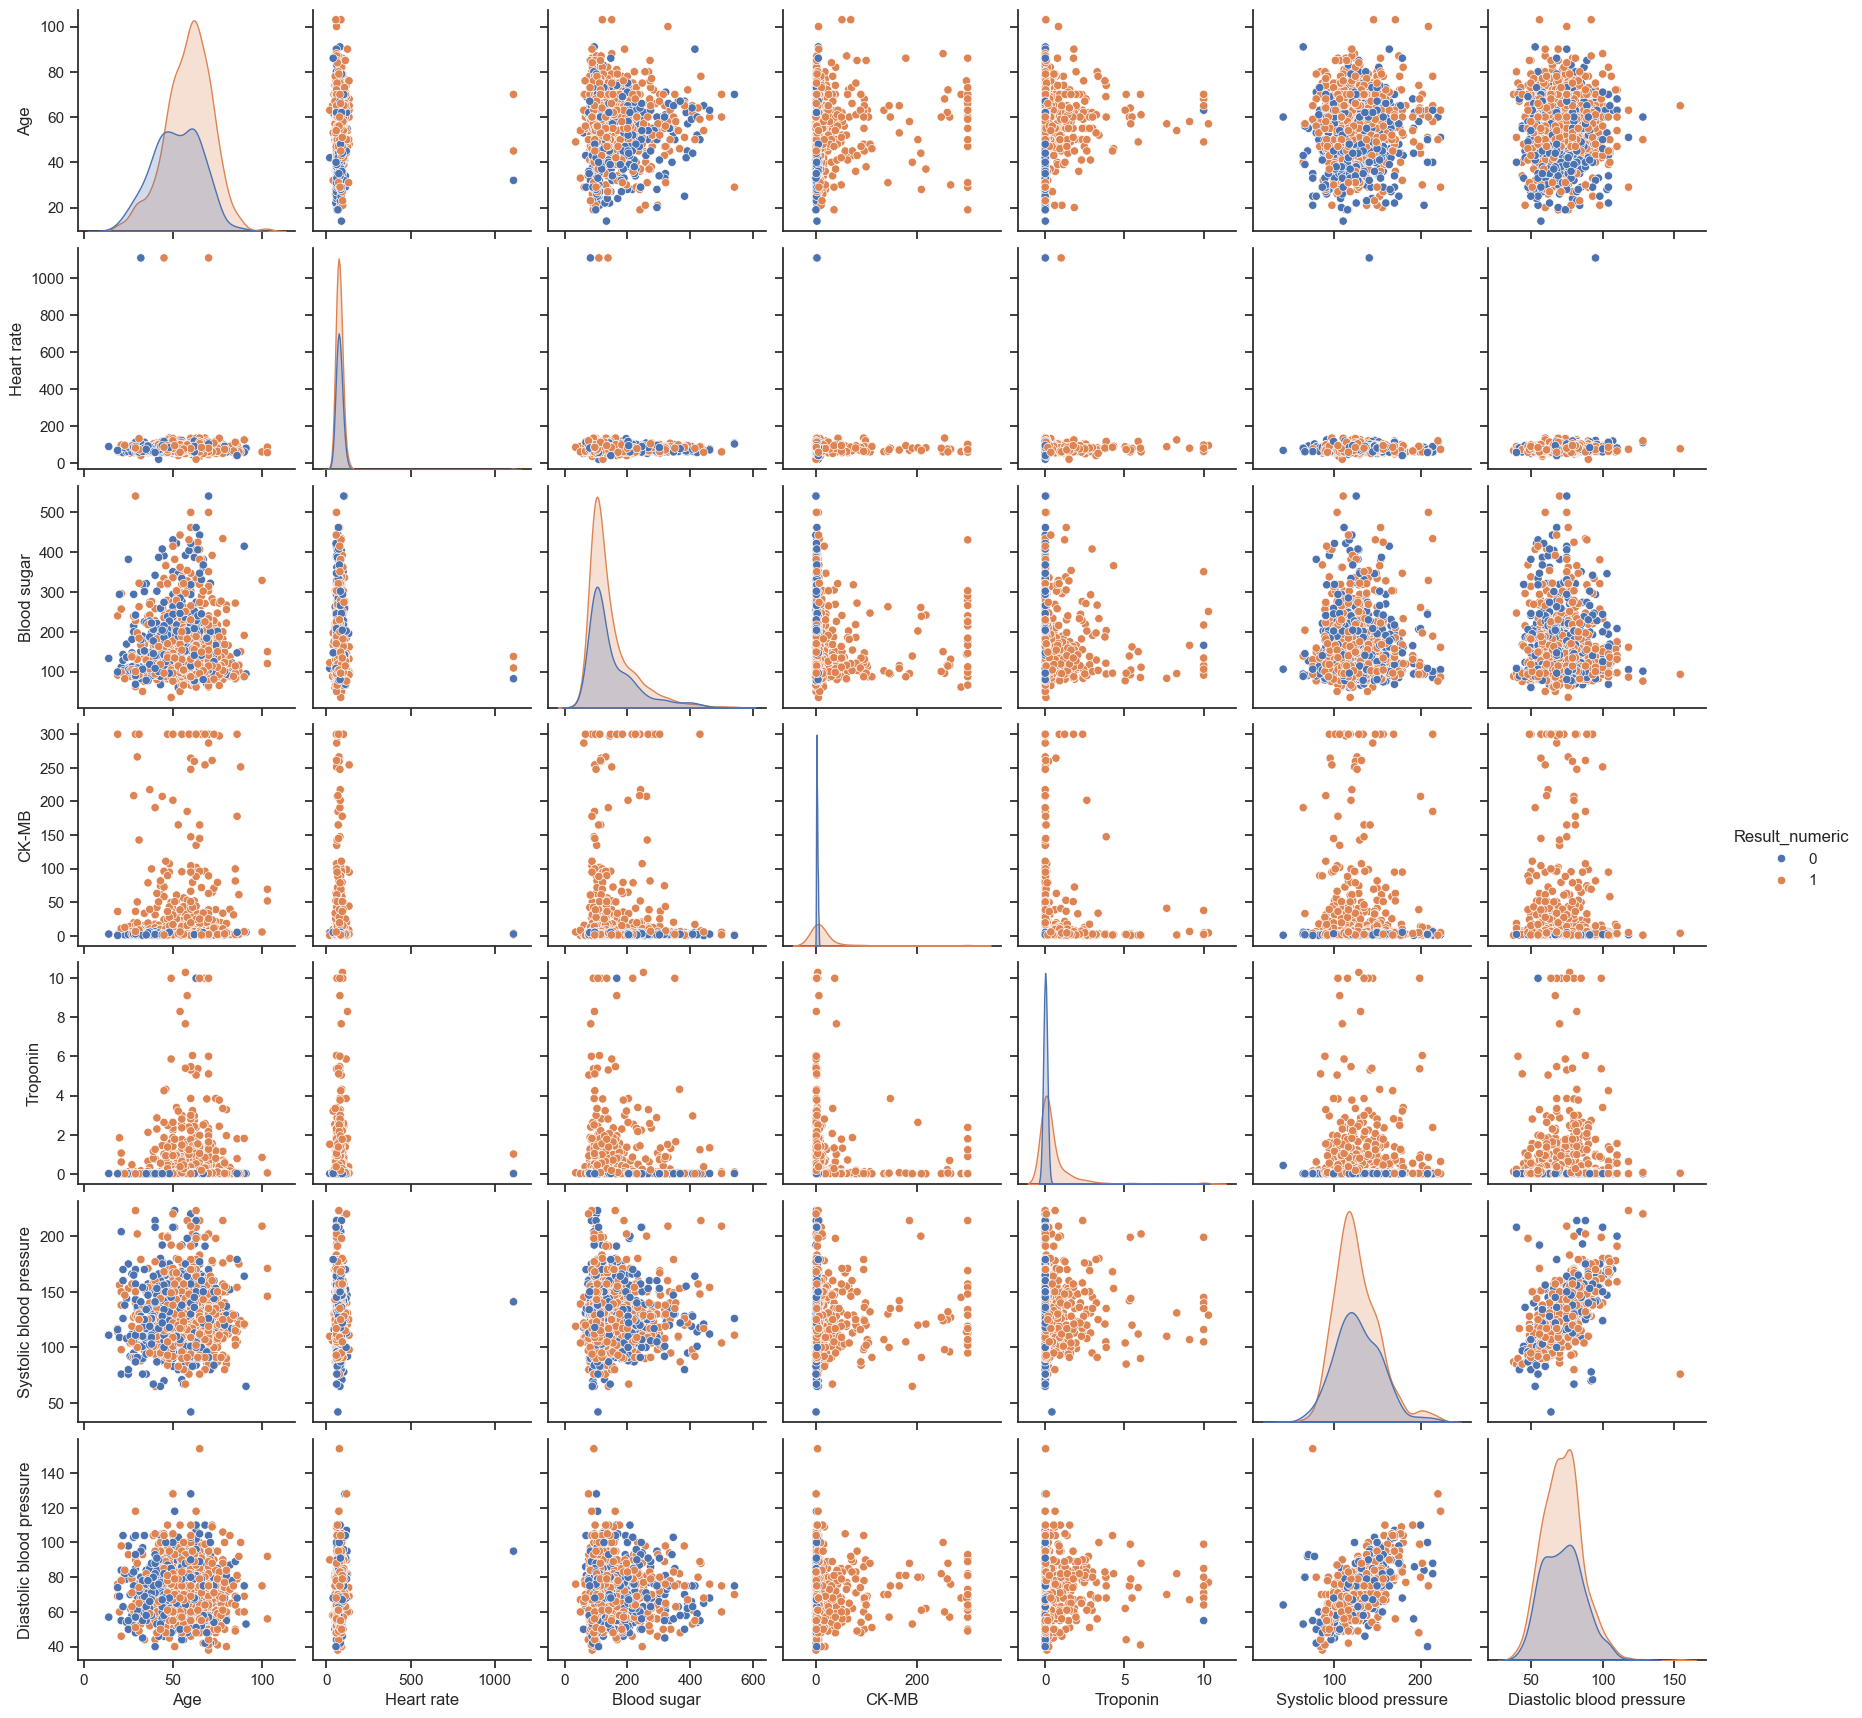

In [33]:
pairplot_features = ['Age', 'Heart rate', 'Blood sugar', 'CK-MB', 'Troponin', 'Result_numeric', 'Systolic blood pressure', 'Diastolic blood pressure']
sns.pairplot(data[pairplot_features], hue='Result_numeric')

<Axes: xlabel='Diastolic blood pressure'>

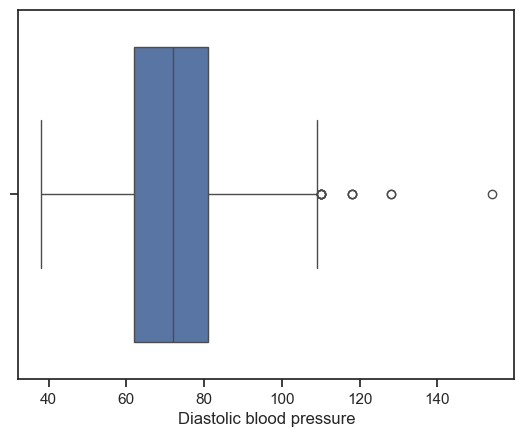

In [34]:
sns.boxplot(x=data['Diastolic blood pressure'])

### sns.boxplot(x='Result_numeric', y='Diastolic blood pressure', data=data)

<Axes: xlabel='Systolic blood pressure'>

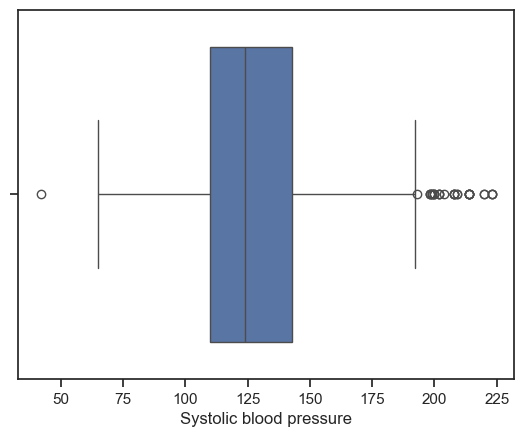

In [35]:
sns.boxplot(x=data['Systolic blood pressure'])

<Axes: xlabel='Result_numeric', ylabel='Systolic blood pressure'>

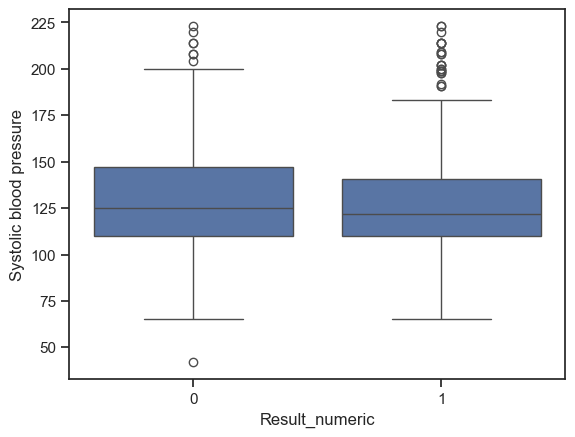

In [36]:
sns.boxplot(x='Result_numeric', y='Systolic blood pressure', data=data)

<Axes: xlabel='Blood sugar'>

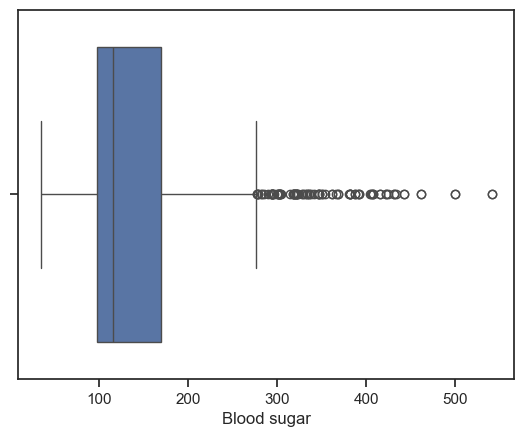

In [37]:
sns.boxplot(x=data['Blood sugar'])

<Axes: xlabel='Result_numeric', ylabel='Blood sugar'>

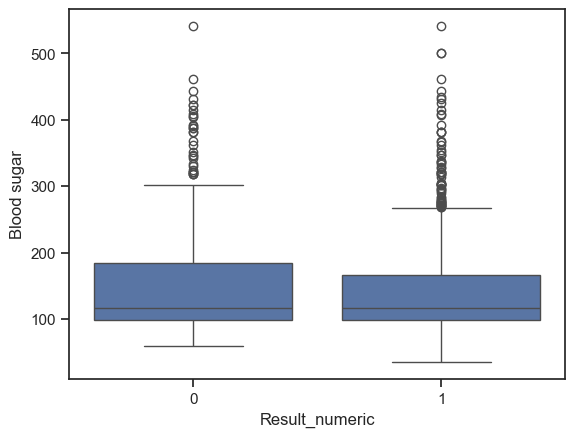

In [38]:
sns.boxplot(x='Result_numeric', y='Blood sugar', data=data)

<Axes: xlabel='Blood sugar'>

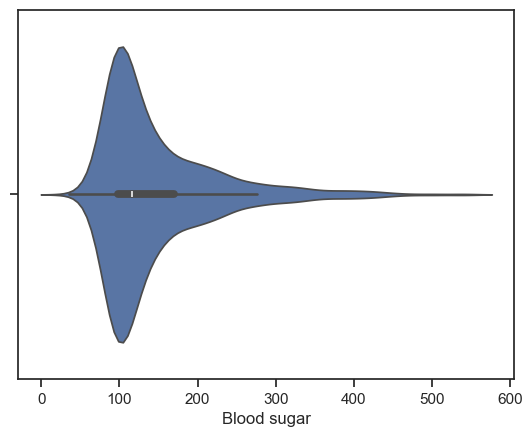

In [39]:
sns.violinplot(x=data['Blood sugar'])

fig, ax = plt.subplots(2, 1, figsize=(10,10))
sns.violinplot(ax=ax[0], x=data['Blood sugar'])
sns.distplot(data['Blood sugar'], ax=ax[1])

<Axes: xlabel='Troponin'>

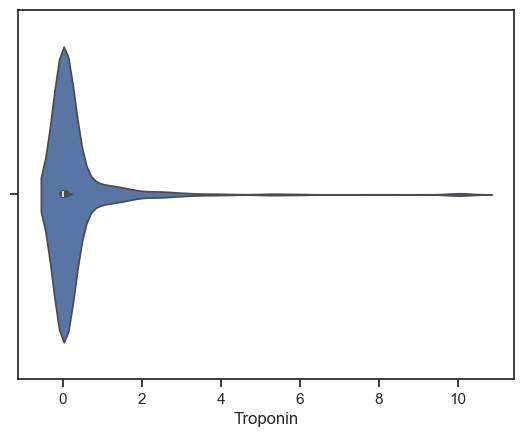

In [40]:
sns.violinplot(x=data['Troponin'])

/var/folders/5x/lbd8871x0gg1k9cphlmq52500000gn/T/ipykernel_7957/1085519150.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Troponin'], ax=ax[1])


<Axes: xlabel='Troponin', ylabel='Density'>

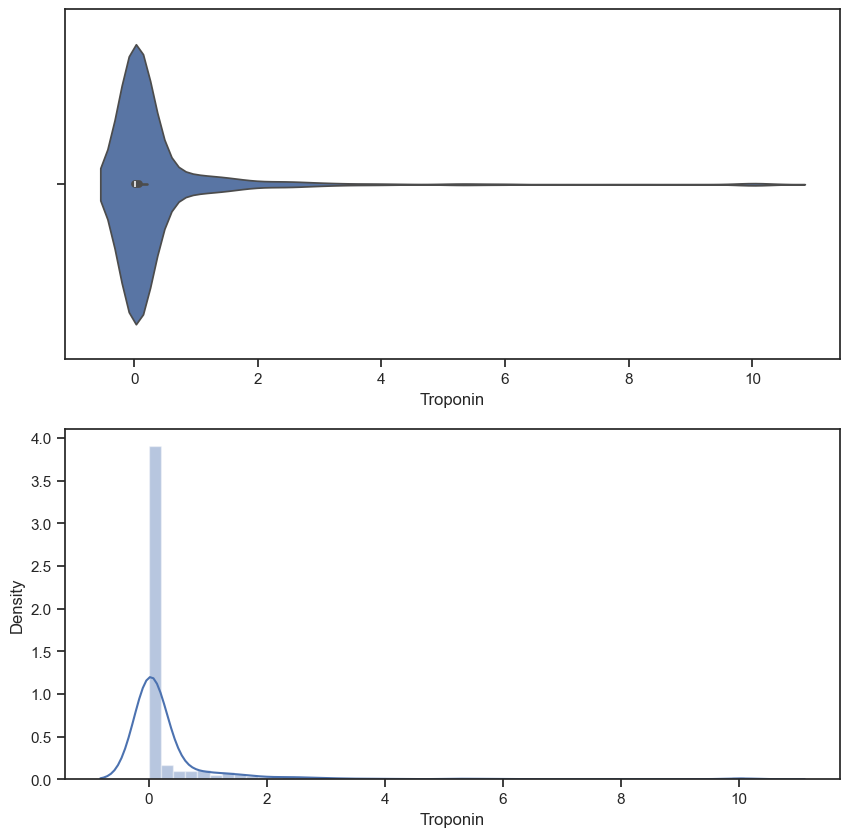

In [41]:
fig, ax = plt.subplots(2, 1, figsize=(10,10))
sns.violinplot(ax=ax[0], x=data['Troponin'])
sns.distplot(data['Troponin'], ax=ax[1])

<Axes: xlabel='CK-MB'>

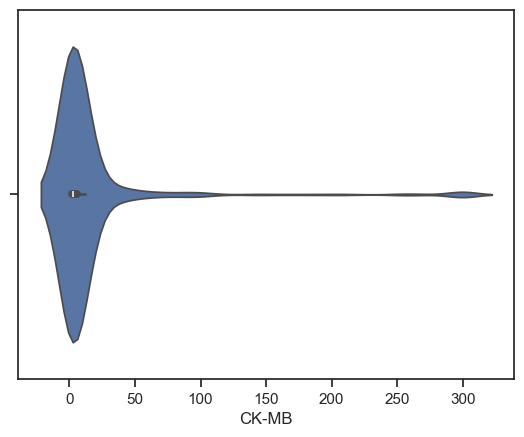

In [42]:
sns.violinplot(x=data['CK-MB'])

/var/folders/5x/lbd8871x0gg1k9cphlmq52500000gn/T/ipykernel_7957/331567953.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['CK-MB'], ax=ax[1])


<Axes: xlabel='CK-MB', ylabel='Density'>

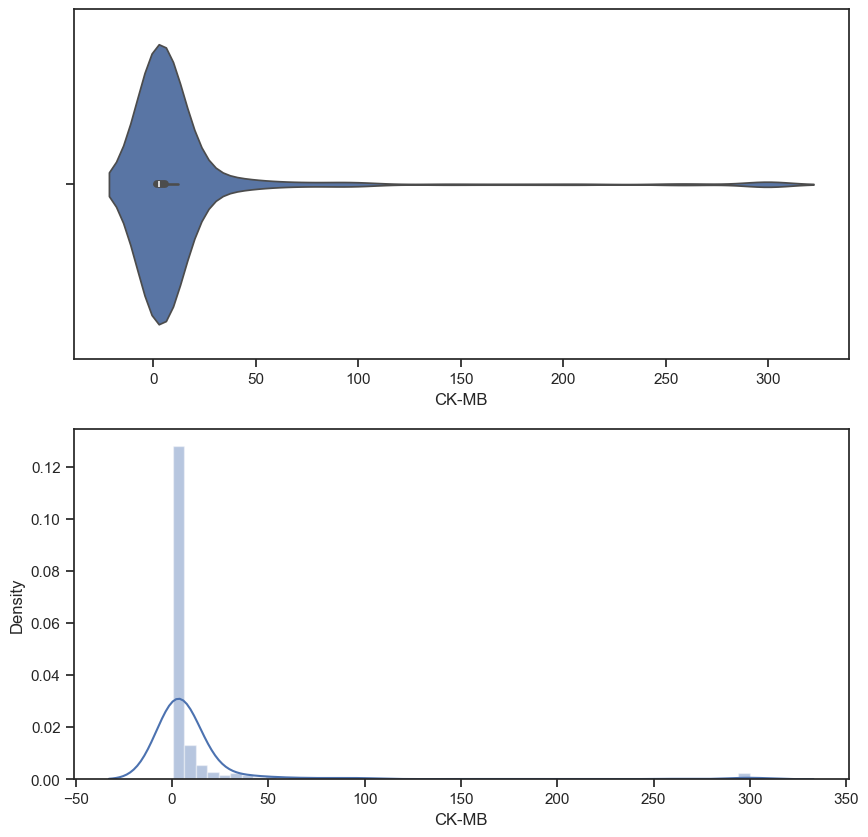

In [43]:
fig, ax = plt.subplots(2, 1, figsize=(10,10))
sns.violinplot(ax=ax[0], x=data['CK-MB'])
sns.distplot(data['CK-MB'], ax=ax[1])

<Axes: xlabel='Diastolic blood pressure'>

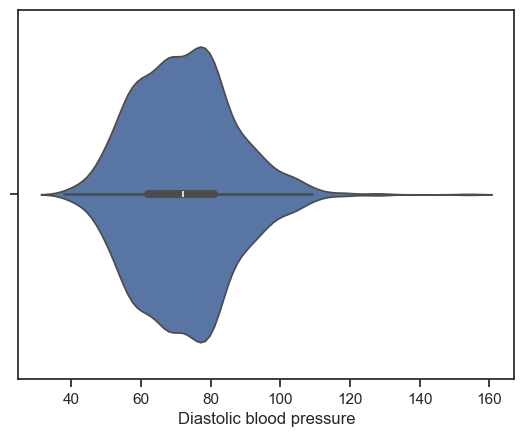

In [44]:
sns.violinplot(x=data['Diastolic blood pressure'])

/var/folders/5x/lbd8871x0gg1k9cphlmq52500000gn/T/ipykernel_7957/2319039363.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Diastolic blood pressure'], ax=ax[1])


<Axes: xlabel='Diastolic blood pressure', ylabel='Density'>

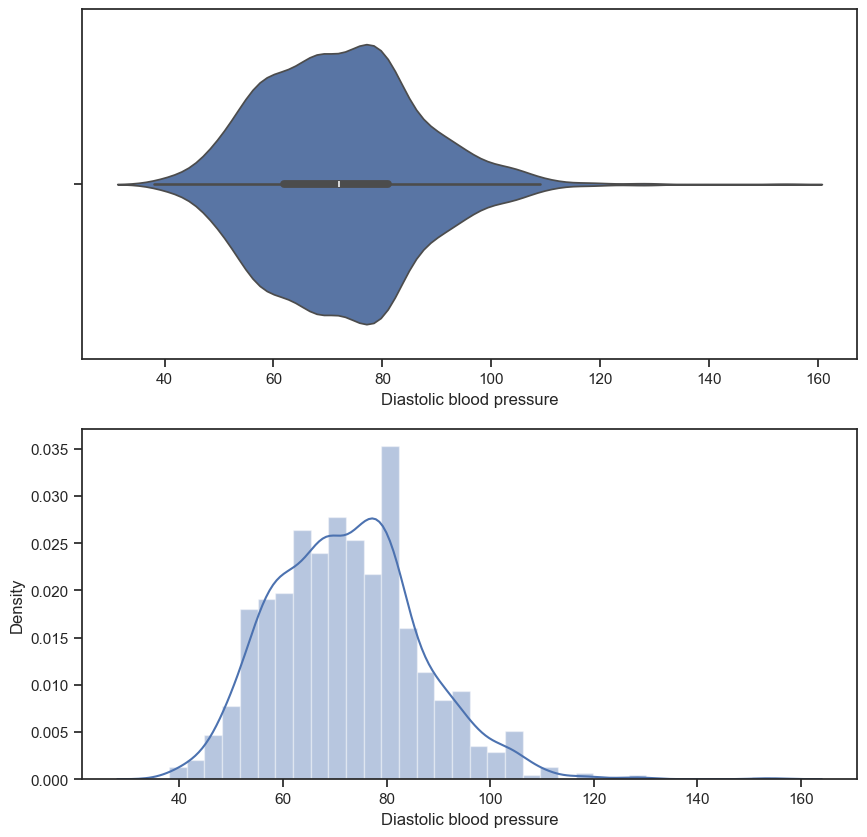

In [45]:
fig, ax = plt.subplots(2, 1, figsize=(10,10))
sns.violinplot(ax=ax[0], x=data['Diastolic blood pressure'])
sns.distplot(data['Diastolic blood pressure'], ax=ax[1])

In [46]:
numeric_data = data.select_dtypes(include=[np.number])

In [47]:
numeric_data.corr()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result_numeric
Age,1.000000,-0.092874,-0.023440,0.017441,0.002614,-0.004193,0.018419,0.088800,0.238097
Gender,-0.092874,1.000000,-0.026781,0.011065,-0.009370,0.006668,0.017527,0.065793,0.094432
Heart rate,-0.023440,-0.026781,1.000000,0.010882,0.108353,-0.019584,-0.013001,0.011180,0.006920
Systolic blood pressure,0.017441,0.011065,0.010882,1.000000,0.586166,0.020807,-0.016396,0.043729,-0.020825
Diastolic blood pressure,0.002614,-0.009370,0.108353,0.586166,1.000000,-0.025614,-0.023403,0.043360,-0.009659
Blood sugar,-0.004193,0.006668,-0.019584,0.020807,-0.025614,1.000000,0.045757,0.021069,-0.033059
CK-MB,0.018419,0.017527,-0.013001,-0.016396,-0.023403,0.045757,1.000000,-0.016008,0.217720
Troponin,0.088800,0.065793,0.011180,0.043729,0.043360,0.021069,-0.016008,1.000000,0.229376
Result_numeric,0.238097,0.094432,0.006920,-0.020825,-0.009659,-0.033059,0.217720,0.229376,1.000000


In [49]:
numeric_data.corr(method='pearson')

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result_numeric
Age,1.000000,-0.092874,-0.023440,0.017441,0.002614,-0.004193,0.018419,0.088800,0.238097
Gender,-0.092874,1.000000,-0.026781,0.011065,-0.009370,0.006668,0.017527,0.065793,0.094432
Heart rate,-0.023440,-0.026781,1.000000,0.010882,0.108353,-0.019584,-0.013001,0.011180,0.006920
Systolic blood pressure,0.017441,0.011065,0.010882,1.000000,0.586166,0.020807,-0.016396,0.043729,-0.020825
Diastolic blood pressure,0.002614,-0.009370,0.108353,0.586166,1.000000,-0.025614,-0.023403,0.043360,-0.009659
Blood sugar,-0.004193,0.006668,-0.019584,0.020807,-0.025614,1.000000,0.045757,0.021069,-0.033059
CK-MB,0.018419,0.017527,-0.013001,-0.016396,-0.023403,0.045757,1.000000,-0.016008,0.217720
Troponin,0.088800,0.065793,0.011180,0.043729,0.043360,0.021069,-0.016008,1.000000,0.229376
Result_numeric,0.238097,0.094432,0.006920,-0.020825,-0.009659,-0.033059,0.217720,0.229376,1.000000


In [50]:
numeric_data.corr(method='kendall')

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result_numeric
Age,1.000000,-0.080399,-0.009838,0.010714,-0.001341,-0.011354,-0.025327,0.249036,0.194909
Gender,-0.080399,1.000000,-0.004962,0.012200,-0.004927,0.011080,0.022539,0.112966,0.094432
Heart rate,-0.009838,-0.004962,1.000000,-0.014652,0.095535,0.010773,0.001111,0.006260,0.000983
Systolic blood pressure,0.010714,0.012200,-0.014652,1.000000,0.455431,0.016678,-0.018579,0.006559,-0.030063
Diastolic blood pressure,-0.001341,-0.004927,0.095535,0.455431,1.000000,0.002553,-0.014107,0.026215,-0.006514
Blood sugar,-0.011354,0.011080,0.010773,0.016678,0.002553,1.000000,0.013453,0.004767,-0.014712
CK-MB,-0.025327,0.022539,0.001111,-0.018579,-0.014107,0.013453,1.000000,-0.032992,0.248530
Troponin,0.249036,0.112966,0.006260,0.006559,0.026215,0.004767,-0.032992,1.000000,0.551855
Result_numeric,0.194909,0.094432,0.000983,-0.030063,-0.006514,-0.014712,0.248530,0.551855,1.000000


In [51]:
numeric_data.corr(method='spearman')

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result_numeric
Age,1.000000,-0.097088,-0.014182,0.016118,-0.001533,-0.016443,-0.037751,0.364720,0.235370
Gender,-0.097088,1.000000,-0.006001,0.014829,-0.005963,0.013504,0.027570,0.136062,0.094432
Heart rate,-0.014182,-0.006001,1.000000,-0.024364,0.139432,0.015453,0.001760,0.009329,0.001189
Systolic blood pressure,0.016118,0.014829,-0.024364,1.000000,0.606070,0.025352,-0.026587,0.010039,-0.036541
Diastolic blood pressure,-0.001533,-0.005963,0.139432,0.606070,1.000000,0.004182,-0.020457,0.037223,-0.007883
Blood sugar,-0.016443,0.013504,0.015453,0.025352,0.004182,1.000000,0.020419,0.006783,-0.017931
CK-MB,-0.037751,0.027570,0.001760,-0.026587,-0.020457,0.020419,1.000000,-0.048484,0.304004
Troponin,0.364720,0.136062,0.009329,0.010039,0.037223,0.006783,-0.048484,1.000000,0.664682
Result_numeric,0.235370,0.094432,0.001189,-0.036541,-0.007883,-0.017931,0.304004,0.664682,1.000000


<Axes: >

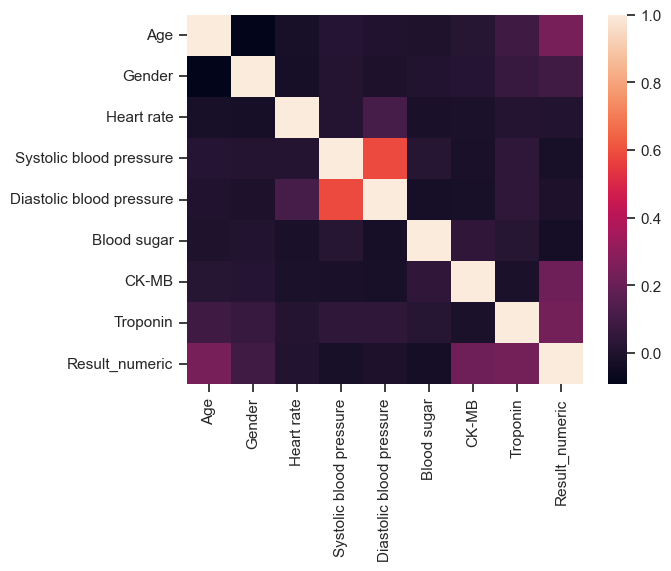

In [52]:
sns.heatmap(numeric_data.corr())

<Axes: >

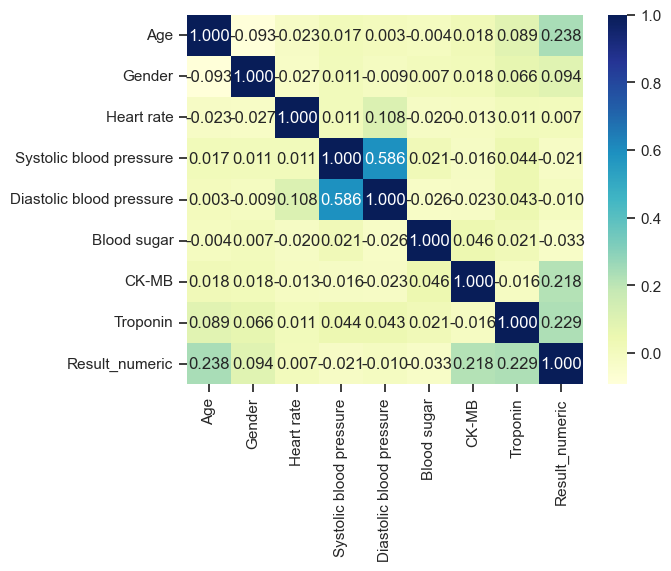

In [53]:
sns.heatmap(numeric_data.corr(), cmap='YlGnBu', annot=True, fmt='.3f')

<Axes: >

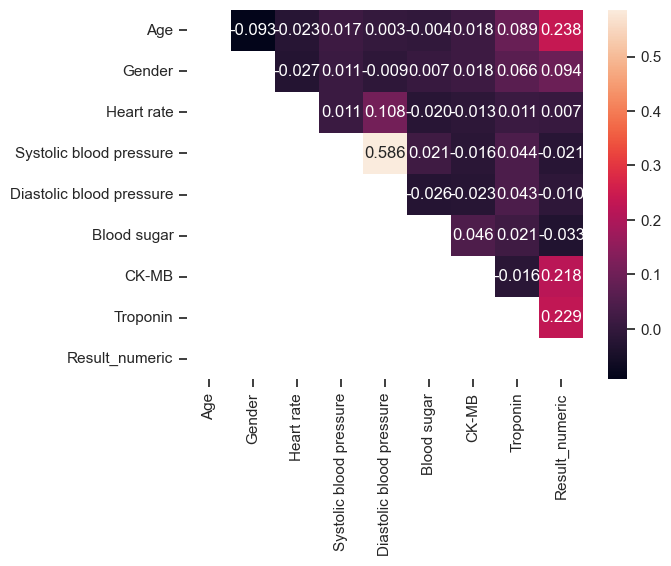

In [54]:
# Треугольный вариант матрицы
mask = np.zeros_like(numeric_data.corr(), dtype=np.bool)
# чтобы оставить нижнюю часть матрицы
# mask[np.triu_indices_from(mask)] = True
# чтобы оставить верхнюю часть матрицы
mask[np.tril_indices_from(mask)] = True
sns.heatmap(numeric_data.corr(), mask=mask, annot=True, fmt='.3f')

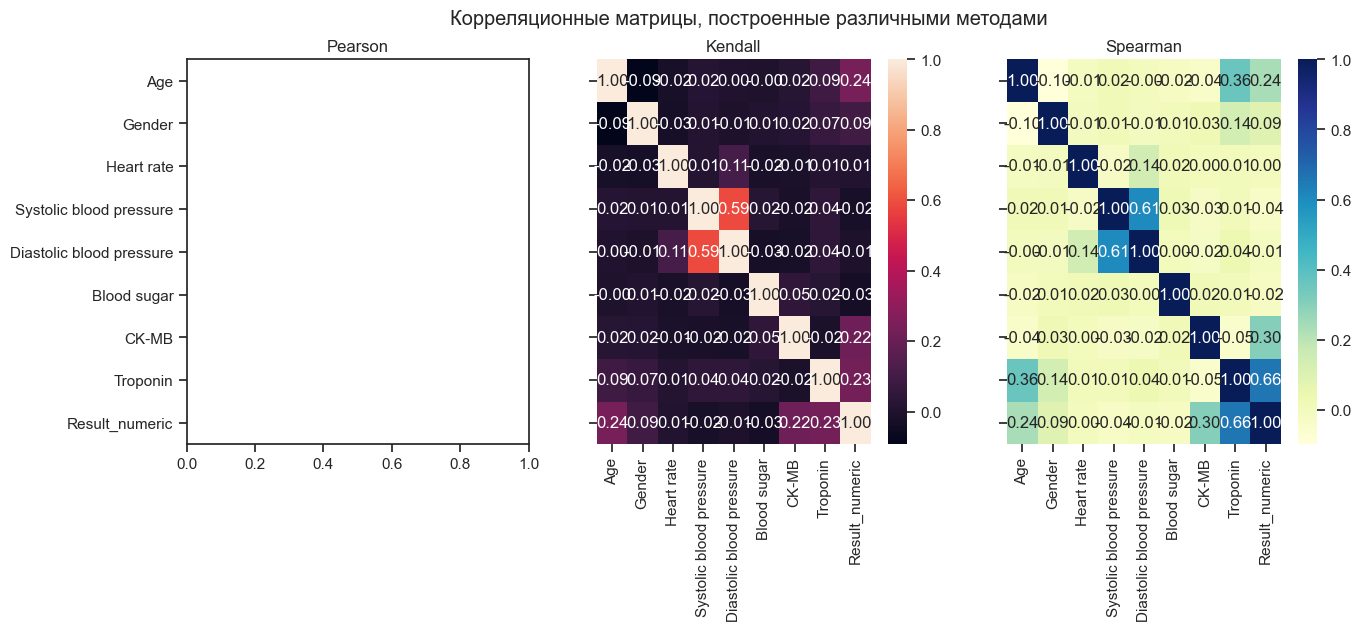

In [57]:
fig, ax = plt.subplots(1, 3, sharex='col', sharey='row', figsize=(15,5))
sns.heatmap(numeric_data.corr(method='pearson'), ax=ax[1], annot=True, fmt='.2f')
sns.heatmap(numeric_data.corr(method='spearman'), cmap='YlGnBu', ax=ax[2], annot=True, fmt='.2f')
fig.suptitle('Корреляционные матрицы, построенные различными методами')
ax[0].title.set_text('Pearson')
ax[1].title.set_text('Kendall')
ax[2].title.set_text('Spearman')

### fig, ax = plt.subplots(1, 3, sharex='col', sharey='row', figsize=(15,5))
sns.heatmap(numeric_data.corr(method='pearson'), cmap='YlGnBu', ax=ax[0], annot=True, fmt='.2f')
sns.heatmap(numeric_data.corr(method='kendall'), cmap='YlGnBu', ax=ax[1], annot=True, fmt='.2f')
sns.heatmap(numeric_data.corr(method='spearman'), cmap='YlGnBu', ax=ax[2], annot=True, fmt='.2f')
fig.suptitle('Корреляционные матрицы, построенные различными методами')
ax[0].title.set_text('Pearson')
ax[1].title.set_text('Kendall')
ax[2].title.set_text('Spearman')

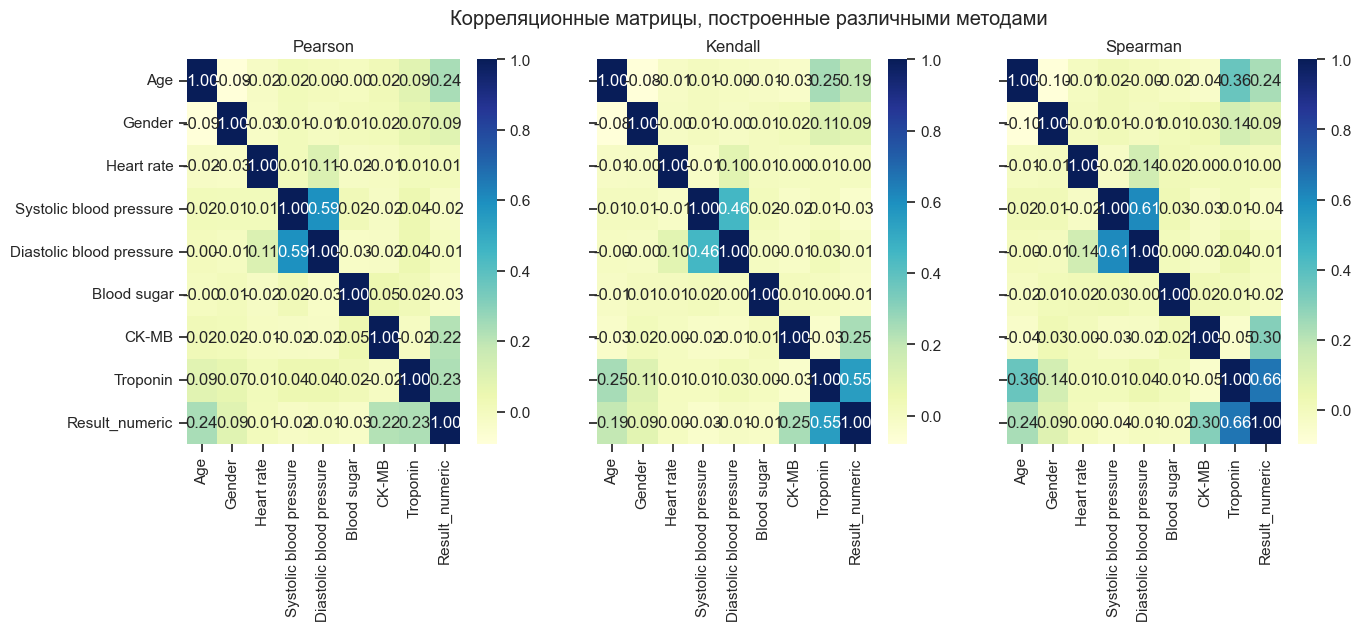

In [60]:
fig, ax = plt.subplots(1, 3, sharex='col', sharey='row', figsize=(15,5))
sns.heatmap(numeric_data.corr(method='pearson'), cmap='YlGnBu', ax=ax[0], annot=True, fmt='.2f')
sns.heatmap(numeric_data.corr(method='kendall'), cmap='YlGnBu', ax=ax[1], annot=True, fmt='.2f')
sns.heatmap(numeric_data.corr(method='spearman'), cmap='YlGnBu', ax=ax[2], annot=True, fmt='.2f')
fig.suptitle('Корреляционные матрицы, построенные различными методами')
ax[0].title.set_text('Pearson')
ax[1].title.set_text('Kendall')
ax[2].title.set_text('Spearman')

### 